# Graph Theory and Social Influence Prediction

**Course:** AIT 525

**Assignment:** Graph Theory and Social Influence Prediction

**By:** Yashu Lanki

## Part 1: Graph Construction and Network Representation

**Dataset overview.** This dataset is the r/MachineLearning reply network from 2014 (Hamilton et al., 2017; Stanford Network Analysis Project, n.d.).

- **Users (nodes):** Reddit commenters in r/MachineLearning.
- **Interactions (edges):** a reply. An edge from A to B means A replied to B's comment, so the graph is directed.
- **Time:** the data is split into 11 monthly networks. This analysis uses the first month (299 users, 411 replies).

In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt

with open('reddit_data/MachineLearning.json') as f:
    data = json.load(f)

print(len(data))

11


In [2]:
month0 = data[0]
print(len(month0))

236


In [3]:
for user, replied_to in month0.items():
    print(user, "->", replied_to)

BeatLeJuce -> ['dhammack', 'bradfordmaster', 'ian_goodfellow', 'randombozo', 'bigattichouse', 'olaf_nij', 'EdwardRaff', 'aidan_morgan', 'bdol', 'j_lyf']
randombozo -> ['BeatLeJuce', 'neuralk']
uber_kerbonaut -> ['datumbox', 'movie_suggestor']
bge0 -> ['ryan1234567890', 'bradfordmaster', 'b0b0b0b', 'prussian_gaocess', 'movie_suggestor']
walloffear -> ['gct']
BillWeld -> ['aidan_morgan']
davis685 -> ['EdwardRaff', 'channikhabra']
Troybatroy -> ['monobarreller']
rasbt -> ['EdwardRaff', 'kau_mad', 'mashito', 'j3camero']
petewilko -> ['ComplexColor']
csferrie -> ['gdahl']
pedrosorio -> ['m1sta']
realAnalysisHalp -> ['TheCaterpillar']
conic_relief -> ['FtYoU', 'hansdieter44', 'sasaram']
closetalcoholic -> ['A_Perfect_Circle']
ml_man -> ['Megatron_McLargeHuge', 'serge_cell']
Hydreigon92 -> ['dylanbyte']
ryptophan -> ['micro_cam', 'multiple_cat']
mosquit0 -> ['momslatin_dadsasian']
asfarley -> ['eigenheckler', 'kejsarmakten']
Ulter -> ['Plazmotech']
duschendestroyer -> ['Thistleknot']
channikh

In [4]:
all_users = set()
for user, replied_to in month0.items():
    all_users.add(user)
    for name in replied_to:
        all_users.add(name)

print(len(all_users))
key_users = len(month0)
users_values_only = len(all_users) - key_users
print(users_values_only)

299
63


In [5]:
G = nx.DiGraph()

for user, replied_to in month0.items():
    for name in replied_to:
        G.add_edge(user, name)

print(G.number_of_nodes())
print(G.number_of_edges())

299
411


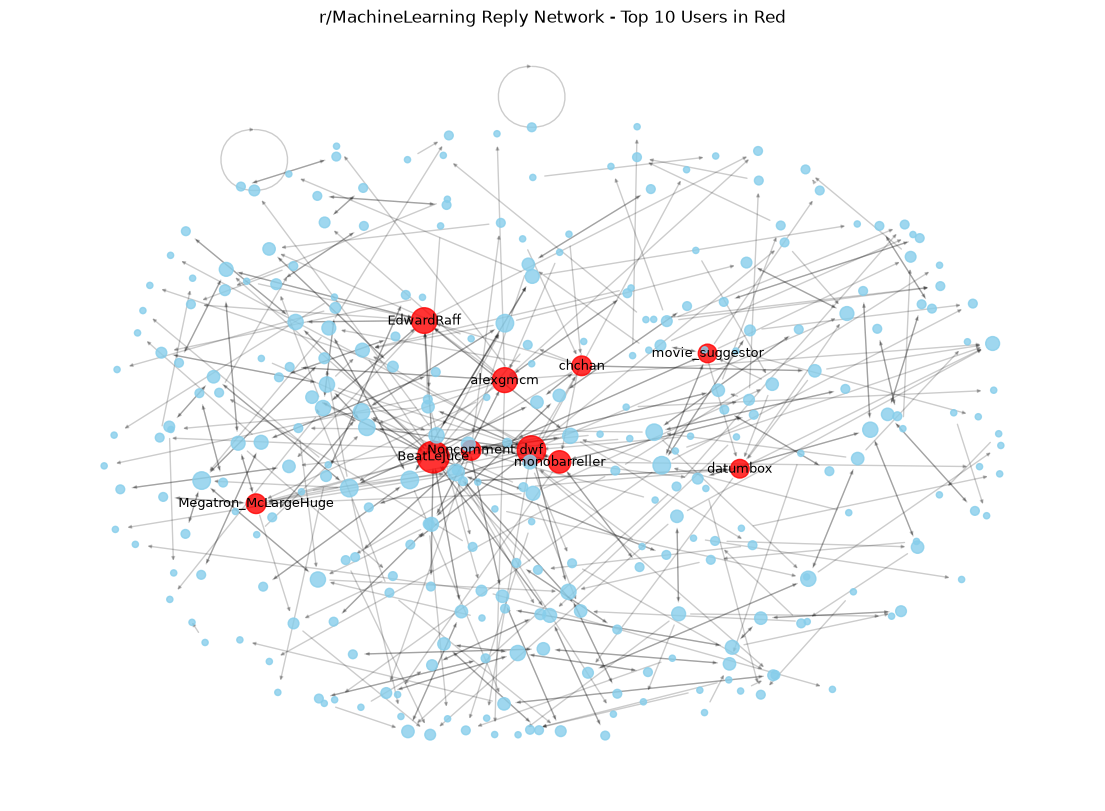

BeatLeJuce 26
dwf 21
EdwardRaff 17
alexgmcm 16
monobarreller 13
Megatron_McLargeHuge 10
chchan 10
Noncomment 10
datumbox 9
movie_suggestor 9


In [6]:
degrees = dict(G.degree())
top_users = sorted(degrees, key=degrees.get, reverse=True)[:10]

node_colors = ['red' if n in top_users else 'skyblue' for n in G.nodes()]
node_sizes = [degrees[n] * 20 for n in G.nodes()]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.3, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2, arrowsize=5)
nx.draw_networkx_labels(G, pos, labels={n: n for n in top_users}, font_size=9)
plt.title('r/MachineLearning Reply Network - Top 10 Users in Red')
plt.axis('off')
plt.show()

for u in top_users:
    print(u, degrees[u])

## Part 2: Random Walks and Social Influence Prediction

In [7]:
# Action = user shows up again in month 1 (posted or was replied to)
month1 = data[1]
active_next_month = set(month1.keys())
for replied_to in month1.values():
    active_next_month.update(replied_to)

took_action = {user: (user in active_next_month) for user in G.nodes()}
print(sum(took_action.values()), 'of', G.number_of_nodes(), 'users took the action')

69 of 299 users took the action


In [8]:
import random

# Walk both ways along replies, so use an undirected copy (no dead ends)
U = G.to_undirected()

def random_walk(graph, start, length=10):
    path = [start]
    current = start
    for _ in range(length):
        neighbors = list(graph.neighbors(current))
        if not neighbors:
            break
        current = random.choice(neighbors)   # hop to a random neighbor
        path.append(current)
    return path

random.seed(42)
print(random_walk(U, 'BeatLeJuce'))

['BeatLeJuce', 'randombozo', 'BeatLeJuce', 'bdol', 'bigattichouse', 'CyberByte', 'bigattichouse', 'BeatLeJuce', 'ian_goodfellow', 'Megatron_McLargeHuge', 'ian_goodfellow']


In [9]:
# Probability = share of nodes visited on walks from the target that took the action
def action_probability(graph, target, num_walks=200, length=10):
    visits = 0
    acted = 0
    for _ in range(num_walks):
        for node in random_walk(graph, target, length)[1:]:
            if node != target:
                visits += 1
                acted += took_action[node]
    return acted / visits if visits else 0

for target in ['BeatLeJuce', 'randombozo', 'walloffear']:
    print(target, '| actually acted:', took_action[target],
          '| predicted probability:', round(action_probability(U, target), 3))

BeatLeJuce | actually acted: True | predicted probability: 0.502
randombozo | actually acted: True | predicted probability: 0.447
walloffear | actually acted: False | predicted probability: 0.384


In [10]:
import pandas as pd

# Influence = how often random walks from every user land on you
random.seed(42)
visit_counts = {n: 0 for n in U.nodes()}
for start in U.nodes():
    for _ in range(50):
        for node in random_walk(U, start, 10)[1:]:
            visit_counts[node] += 1

total = sum(visit_counts.values())
scores = pd.DataFrame({
    'random_walk': {n: c / total for n, c in visit_counts.items()},
    'degree': nx.degree_centrality(G),
    'betweenness': nx.betweenness_centrality(G),
}).sort_values('random_walk', ascending=False)

print(scores.head(10).round(4))
print(scores.corr().round(2))

                      random_walk  degree  betweenness
BeatLeJuce                 0.0202  0.0872       0.0963
dwf                        0.0184  0.0705       0.0747
alexgmcm                   0.0178  0.0537       0.0068
EdwardRaff                 0.0159  0.0570       0.0309
monobarreller              0.0138  0.0436       0.0283
Noncomment                 0.0123  0.0336       0.0009
datumbox                   0.0103  0.0302       0.0165
Megatron_McLargeHuge       0.0097  0.0336       0.0152
chchan                     0.0092  0.0336       0.0256
movie_suggestor            0.0087  0.0302       0.0170
             random_walk  degree  betweenness
random_walk         1.00    0.92         0.72
degree              0.92    1.00         0.82
betweenness         0.72    0.82         1.00


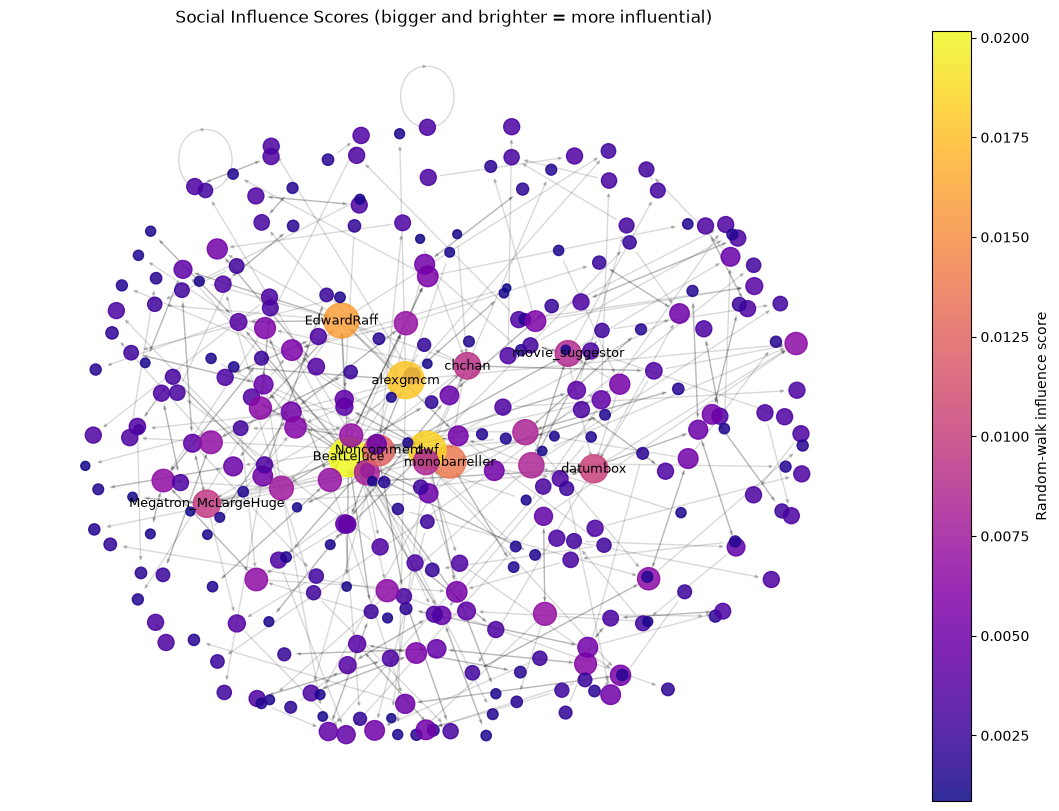

In [11]:
plt.figure(figsize=(14, 10))
nodes = list(G.nodes())
s = [scores.loc[n, 'random_walk'] for n in nodes]
max_s = max(s)

d = nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=s, cmap='plasma',
                           node_size=[x / max_s * 800 for x in s], alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.15, arrowsize=5)
nx.draw_networkx_labels(G, pos, labels={n: n for n in scores.head(10).index}, font_size=9)
plt.colorbar(d, label='Random-walk influence score')
plt.title('Social Influence Scores (bigger and brighter = more influential)')
plt.axis('off')
plt.show()

**Summary of influence results.** The most influential users by random-walk score are BeatLeJuce, dwf, alexgmcm, EdwardRaff, and monobarreller. Random walks keep landing on these users because they have many reply connections, which is why the random-walk score closely tracks degree centrality (correlation 0.92) (Hagberg et al., 2008). Betweenness centrality tells a different story: it measures how often a user sits on the shortest path between other users, acting as a bridge between groups (Freeman, 1977). BeatLeJuce and dwf rank high on both, so they are active *and* connect separate parts of the community. alexgmcm, by contrast, ranks #3 by random walk but has almost no betweenness (0.007). They talk to many users but aren't a bridge between groups, so their influence stays mostly within one cluster.

## Part 3: Algorithm Development for Social Influence Prediction

In [12]:
# Build one row of features per user from the Part 2 results
random.seed(42)
features = scores.copy()
features['friends_acted'] = [action_probability(U, u) for u in features.index]  # friends' actions (random walks)
features['label'] = [took_action[u] for u in features.index]                    # what actually happened

print(features.head())

               random_walk    degree  betweenness  friends_acted  label
BeatLeJuce        0.020167  0.087248     0.096253       0.503885   True
dwf               0.018435  0.070470     0.074745       0.477183   True
alexgmcm          0.017839  0.053691     0.006821       0.363193   True
EdwardRaff        0.015926  0.057047     0.030887       0.383157   True
monobarreller     0.013759  0.043624     0.028281       0.331297  False


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve

X = features[['friends_acted', 'random_walk', 'degree', 'betweenness']]
y = features['label']

# Logistic regression turns the features into a probability of acting.
# 5-fold cross-validation: every user is predicted by a model that never saw them.
model = make_pipeline(StandardScaler(), LogisticRegression())
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
predicted = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

print('AUC, friends only (Part 2 random walk):', round(roc_auc_score(y, features['friends_acted']), 3))
print('AUC, full model (friends + influence):  ', round(roc_auc_score(y, predicted), 3))

AUC, friends only (Part 2 random walk): 0.579
AUC, full model (friends + influence):   0.657


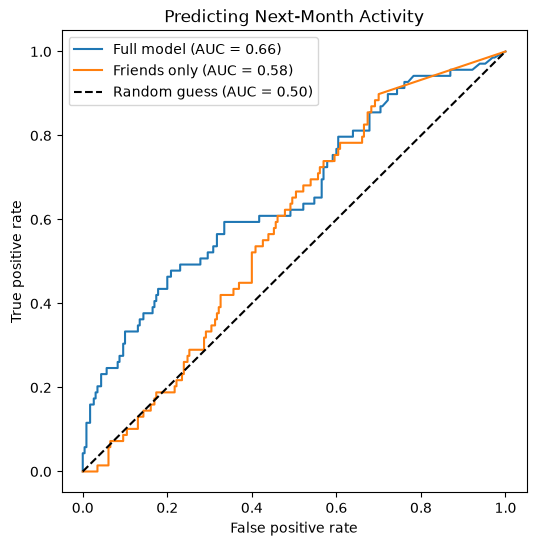

In [14]:
# ROC curve: the further the line bows above the diagonal, the better the model
fpr_f, tpr_f, _ = roc_curve(y, features['friends_acted'])
fpr_m, tpr_m, _ = roc_curve(y, predicted)

plt.figure(figsize=(6, 6))
plt.plot(fpr_m, tpr_m, label=f'Full model (AUC = {roc_auc_score(y, predicted):.2f})')
plt.plot(fpr_f, tpr_f, label=f'Friends only (AUC = {roc_auc_score(y, features["friends_acted"]):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess (AUC = 0.50)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Predicting Next-Month Activity')
plt.legend()
plt.show()

**How the algorithm works.** For each user, the model combines four numbers from Part 2: how often random walks from the user reach friends who took the action, plus the user's own random-walk influence, degree, and betweenness scores. A logistic regression turns these into a probability that the user stays active next month (Pedregosa et al., 2011). Five-fold cross-validation means every user is predicted by a model that never saw them during training.

**Evaluation metric.** Performance is measured with AUC (area under the ROC curve). AUC is the chance that the model ranks a randomly chosen active user above a randomly chosen inactive one: 0.50 is random guessing, 1.0 is perfect (Fawcett, 2006).

**Performance.** Using friends' actions alone gives an AUC of 0.58. Adding the influence scores raises it to 0.66, because they capture the user's *own* activity in the network, not just their friends'. An AUC of 0.66 is moderate: clearly better than guessing, but far from perfect. Other factors matter too, such as a user's interests, free time, or activity outside this subreddit, and none of these are in the reply graph.

## Ethical Considerations

**Applications.** Graph-based influence prediction powers social media recommendations: platforms use who interacts with whom to suggest content and target the most influential users so ideas spread further (Kempe et al., 2003). In bioinformatics, the same tools run on protein-interaction networks, where highly connected "hub" proteins help identify genes linked to disease (Barabási et al., 2011).

**Risks.** The same ability to find influential users can be used for manipulation. Misinformation seeded through well-connected accounts can go viral, and false news has been shown to spread farther and faster than true news online (Vosoughi et al., 2018).

**Privacy and autonomy.** This dataset uses public Reddit replies, but public does not mean fair game. Scoring people's influence still profiles them in ways they never agreed to or expected (Zimmer, 2010). Predicting whether someone will stay active, and then nudging them based on that prediction, can also undermine their autonomy.

**Mitigation strategies.** In line with character education principles of honesty and respect for persons, these systems should explain their scores openly, telling users what is measured and why. They should anonymize data, use only what's necessary, and be checked for unfair impacts, consistent with the transparency and fairness principles common to AI ethics guidelines (Jobin et al., 2019).

## References

Barabási, A.-L., Gulbahce, N., & Loscalzo, J. (2011). Network medicine: A network-based approach to human disease. *Nature Reviews Genetics*, *12*(1), 56–68. https://doi.org/10.1038/nrg2918

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, *27*(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, *40*(1), 35–41. https://doi.org/10.2307/3033543

Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. In G. Varoquaux, T. Vaught, & J. Millman (Eds.), *Proceedings of the 7th Python in Science Conference* (pp. 11–15).

Hamilton, W. L., Zhang, J., Danescu-Niculescu-Mizil, C., Jurafsky, D., & Leskovec, J. (2017). Loyalty in online communities. *Proceedings of the International AAAI Conference on Web and Social Media*, *11*(1), 540–543.

Jobin, A., Ienca, M., & Vayena, E. (2019). The global landscape of AI ethics guidelines. *Nature Machine Intelligence*, *1*(9), 389–399. https://doi.org/10.1038/s42256-019-0088-2

Kempe, D., Kleinberg, J., & Tardos, É. (2003). Maximizing the spread of influence through a social network. In *Proceedings of the Ninth ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 137–146). https://doi.org/10.1145/956750.956769

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

Stanford Network Analysis Project. (n.d.). *Reddit user interaction networks* [Data set]. Stanford University. Retrieved October 7, 2026, from https://snap.stanford.edu/data/web-RedditNetworks.html

Vosoughi, S., Roy, D., & Aral, S. (2018). The spread of true and false news online. *Science*, *359*(6380), 1146–1151. https://doi.org/10.1126/science.aap9559

Zimmer, M. (2010). "But the data is already public": On the ethics of research in Facebook. *Ethics and Information Technology*, *12*(4), 313–325. https://doi.org/10.1007/s10676-010-9227-5